In [1]:
"""
PROJECT: Flower Species Classifier 🌸🌺🌼
Classify iris flowers into 3 species based on petal/sepal measurements
"""

'\nPROJECT: Flower Species Classifier 🌸🌺🌼\nClassify iris flowers into 3 species based on petal/sepal measurements\n'

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
print("🌸 FLOWER SPECIES CLASSIFIER")
print("=" * 60)

🌸 FLOWER SPECIES CLASSIFIER


In [4]:
# Load Iris dataset
print("\n📊 Loading Iris flower dataset...")
iris = load_iris()
X = iris.data
y = iris.target


📊 Loading Iris flower dataset...


In [5]:
species_names = iris.target_names
feature_names = iris.feature_names

In [6]:
print(f"✓ Total samples: {len(X)}")
print(f"✓ Features: {len(feature_names)}")
print(f"✓ Species: {', '.join(species_names)}")

print("\nFeatures:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

✓ Total samples: 150
✓ Features: 4
✓ Species: setosa, versicolor, virginica

Features:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)



📈 Visualizing flower measurements...
✓ Data visualization saved


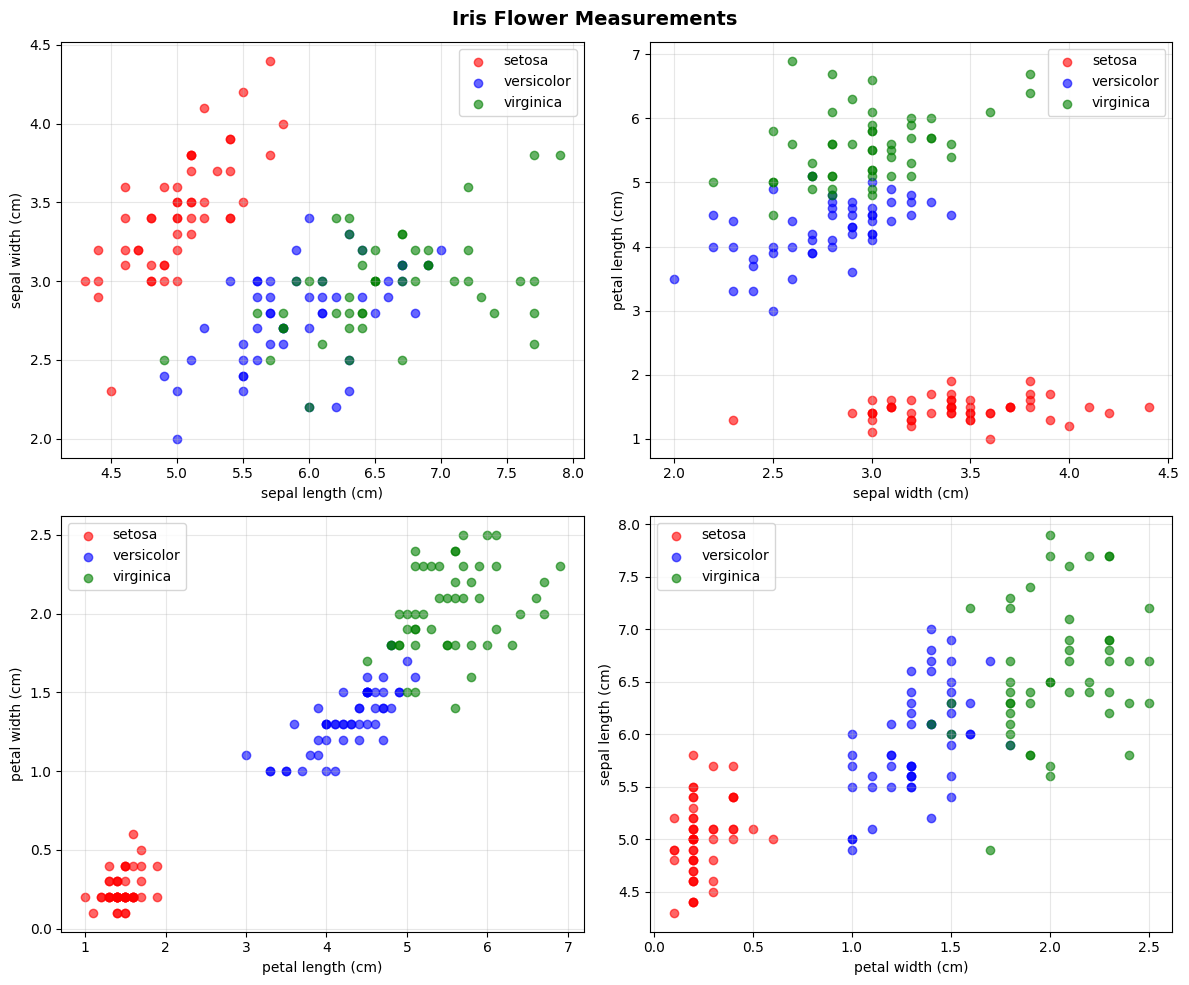

In [7]:
# Visualize data
print("\n📈 Visualizing flower measurements...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ['red', 'blue', 'green']

for i in range(4):
    ax = axes[i//2, i%2]
    for species_idx in range(3):
        mask = y == species_idx
        ax.scatter(X[mask, i], X[mask, (i+1)%4], 
                  c=colors[species_idx], 
                  label=species_names[species_idx],
                  alpha=0.6)
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[(i+1)%4])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Iris Flower Measurements', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iris_data_visualization.png', dpi=150, bbox_inches='tight')
print("✓ Data visualization saved")

In [8]:
# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Training samples: {len(X_train)}")
print(f"✓ Test samples: {len(X_test)}")


✓ Training samples: 120
✓ Test samples: 30


In [9]:
# Build model
print("\n🧠 Building flower classifier...")
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')  # 3 species
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()


🧠 Building flower classifier...


C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train
print("\n🏋️  Training classifier...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

print("✓ Training complete!")


🏋️  Training classifier...
✓ Training complete!


In [11]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n📊 Test Accuracy: {test_acc*100:.2f}%")


📊 Test Accuracy: 96.67%


✓ Training charts saved


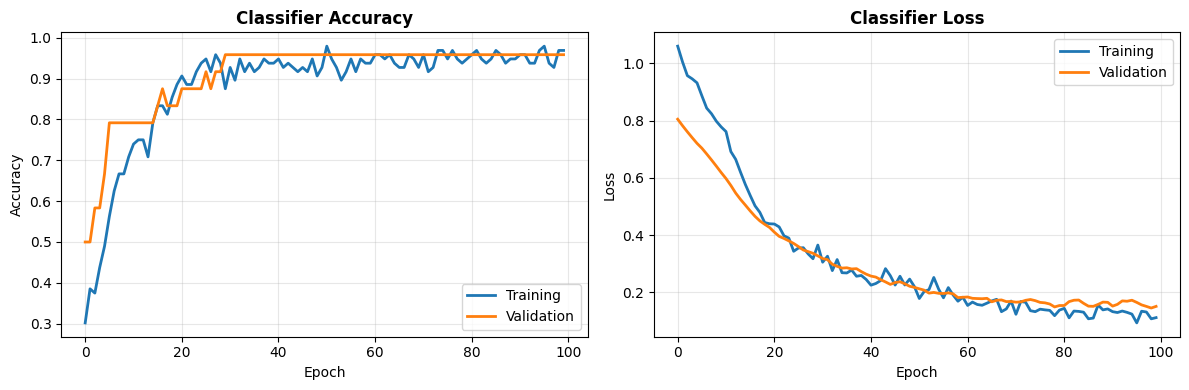

In [12]:
# Visualize training
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Classifier Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Classifier Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('iris_training.png', dpi=150, bbox_inches='tight')
print("✓ Training charts saved")

In [13]:
# Make predictions
predictions = model.predict(X_test_scaled, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

✓ Confusion matrix saved


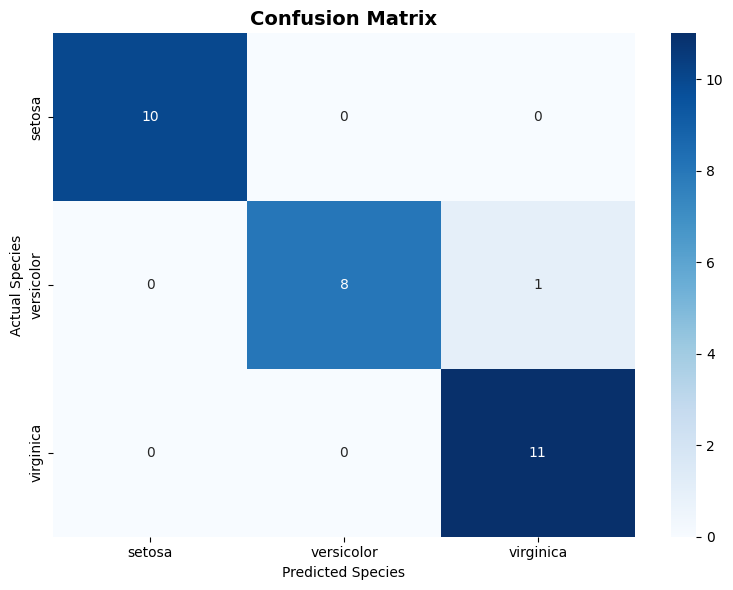

In [18]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names,
            yticklabels=species_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
print("✓ Confusion matrix saved")

In [19]:
# Show predictions
print("\n🔮 Sample Predictions:")
print("=" * 90)
print(f"{'Sepal L':<10} {'Sepal W':<10} {'Petal L':<10} {'Petal W':<10} {'Predicted':<15} {'Actual':<15} {'✓/✗'}")
print("-" * 90)

for i in range(min(15, len(X_test))):
    pred_species = species_names[predicted_classes[i]]
    actual_species = species_names[y_test[i]]
    correct = "✓" if predicted_classes[i] == y_test[i] else "✗"
    confidence = predictions[i][predicted_classes[i]] * 100
    
    print(f"{X_test[i][0]:<10.2f} {X_test[i][1]:<10.2f} "
          f"{X_test[i][2]:<10.2f} {X_test[i][3]:<10.2f} "
          f"{pred_species:<15} {actual_species:<15} {correct}")

print("=" * 90)


🔮 Sample Predictions:
Sepal L    Sepal W    Petal L    Petal W    Predicted       Actual          ✓/✗
------------------------------------------------------------------------------------------
6.10       2.80       4.70       1.20       versicolor      versicolor      ✓
5.70       3.80       1.70       0.30       setosa          setosa          ✓
7.70       2.60       6.90       2.30       virginica       virginica       ✓
6.00       2.90       4.50       1.50       versicolor      versicolor      ✓
6.80       2.80       4.80       1.40       versicolor      versicolor      ✓
5.40       3.40       1.50       0.40       setosa          setosa          ✓
5.60       2.90       3.60       1.30       versicolor      versicolor      ✓
6.90       3.10       5.10       2.30       virginica       virginica       ✓
6.20       2.20       4.50       1.50       virginica       versicolor      ✗
5.80       2.70       3.90       1.20       versicolor      versicolor      ✓
6.50       3.20       5.10

In [20]:
# Test on new flower
print("\n🌺 Testing on a new flower:")
print("-" * 60)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # Typical Setosa measurements
new_flower_scaled = scaler.transform(new_flower)
prediction = model.predict(new_flower_scaled, verbose=0)
predicted_species = species_names[np.argmax(prediction)]
confidence = prediction[0][np.argmax(prediction)] * 100

print(f"Measurements: Sepal L={new_flower[0][0]}, Sepal W={new_flower[0][1]}, "
      f"Petal L={new_flower[0][2]}, Petal W={new_flower[0][3]}")
print(f"Prediction: {predicted_species}")
print(f"Confidence: {confidence:.1f}%")

print("\n🎉 Flower classifier complete!")
print(f"Can identify iris species with {test_acc*100:.1f}% accuracy!")


🌺 Testing on a new flower:
------------------------------------------------------------
Measurements: Sepal L=5.1, Sepal W=3.5, Petal L=1.4, Petal W=0.2
Prediction: setosa
Confidence: 100.0%

🎉 Flower classifier complete!
Can identify iris species with 96.7% accuracy!
